# Linear Regression

Linear regression is a basic model for machine learning. It is quite simple and is based on the y = mx + b function of the line. In this notebook this function will be represented as: $$f_{w,b}(x) = wx + b$$ since m will be our number of rows.

In this notebook I will be implementing linear regression from scratch, without the use of scikit-learn or other ML libraries. This with the objective of learning how the algorithm works behind the scenes.




In [281]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

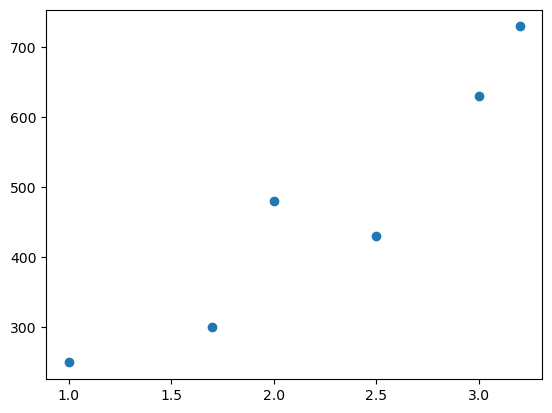

In [282]:
x_values = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 3.2])
y_values = np.array([250.0, 300.0, 480.0,  430.0, 630.0, 730.0])

plt.scatter(x_values, y_values)
plt.show()

In [283]:
#This function isnt technically indispensable. However it is a key function so I can see whats happening (see how the cost goes down after each iteration)
def compute_cost(x, y, w, b):
    cost = 0
    m = x.shape[0]
    for i in range(m):
        f_wb = (w * x[i]) + b
        cost += (f_wb - y[i]) ** 2
    total_cost = (cost / (2 * m))
    return total_cost
        
        

In [284]:
def compute_gradient(x, y, w, b):
    
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    #get partial derivatives:
    for i in range(m):
        f_wb = (w * x[i]) + b
        dj_dw += (f_wb - y[i]) * x[i]
        dj_db += f_wb - y[i]

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db
    

In [285]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters):

    w = w_in
    b = b_in
    cost_history = []
    w_history = []
    b_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        #print progress every 10%. Using floor div as a good practice for step count
        if i % (num_iters // 10) == 0:
            cost = compute_cost(x, y, w, b)
            print(f"Iteration {i:4}: Costo {cost:0.4e} | W: {w:0.3f}, b: {b:0.3f}")

    return w, b
    

In [286]:
initial_w = 0
initial_b = 0
iterations = 2500
tmp_alpha = 0.01
#convert pandas series to np arrays
x_train = x_values
y_train = y_values

x_train = x_train.astype(np.float64)
y_train = y_train.astype(np.float64)

w_final, b_final = gradient_descent(x_train, y_train, initial_w, initial_b, tmp_alpha, iterations)

print(f"\Final values -> w: {w_final:0.2f}, b: {b_final:0.2f}")

Iteration    0: Costo 1.0941e+05 | W: 11.702, b: 4.700
Iteration  250: Costo 1.9038e+03 | W: 186.145, b: 59.336
Iteration  500: Costo 1.8435e+03 | W: 190.774, b: 47.990
Iteration  750: Costo 1.8049e+03 | W: 194.480, b: 38.906
Iteration 1000: Costo 1.7801e+03 | W: 197.447, b: 31.632
Iteration 1250: Costo 1.7642e+03 | W: 199.822, b: 25.809
Iteration 1500: Costo 1.7541e+03 | W: 201.724, b: 21.147
Iteration 1750: Costo 1.7475e+03 | W: 203.247, b: 17.414
Iteration 2000: Costo 1.7434e+03 | W: 204.466, b: 14.426
Iteration 2250: Costo 1.7407e+03 | W: 205.442, b: 12.033
\Final values -> w: 206.22, b: 10.12


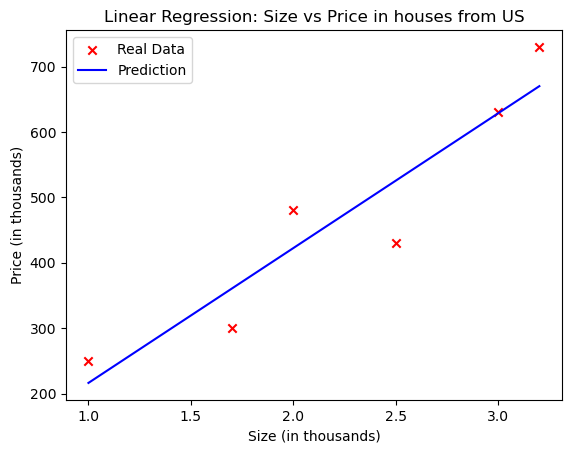

In [287]:
plt.scatter(x_train, y_train, marker='x', c='r', label='Real Data')

m = x_train.shape[0]
predicted_y = np.zeros(m)
for i in range(m):
    predicted_y[i] = w_final * x_train[i] + b_final
plt.plot(x_train, predicted_y, c='b', label='Prediction')

plt.title("Linear Regression: Size vs Price in houses from US")
plt.ylabel('Price (in thousands)')
plt.xlabel('Size (in thousands)')
plt.legend() 
plt.show()